In [5]:
# Blank Sample QC Anomaly Detection MVP

"""
Purpose
-------
This notebook investigates Blank Sample QC anomalies
using historical QC laboratory data.

Blank samples are used to detect:
- contamination
- carryover
- background signal
- preparation-related interference

Expected blank behaviour:
- near-zero values
- low variance
- stable temporal behaviour

Potential anomalies:
- elevated contamination
- analyte-specific spikes
- contamination drift
- contextual instrument instability

This MVP combines:
- rule-based QC checks
- rolling statistical behaviour
- Isolation Forest anomaly detection
- risk prioritisation

to support automated blank anomaly assessment.
"""

'\nPurpose\n-------\nThis notebook investigates Blank Sample QC anomalies\nusing historical QC laboratory data.\n\nBlank samples are used to detect:\n- contamination\n- carryover\n- background signal\n- preparation-related interference\n\nExpected blank behaviour:\n- near-zero values\n- low variance\n- stable temporal behaviour\n\nPotential anomalies:\n- elevated contamination\n- analyte-specific spikes\n- contamination drift\n- contextual instrument instability\n\nThis MVP combines:\n- rule-based QC checks\n- rolling statistical behaviour\n- Isolation Forest anomaly detection\n- risk prioritisation\n\nto support automated blank anomaly assessment.\n'

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [7]:
df = pd.read_csv(
    "QC_Sample_Data.csv"
)

print(df.shape)

df.head()

(1201152, 18)


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,RECOVERY,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,RELATIVE_PERCENT_DIFFERENCE,STANDARD_STATUS,RECOVERY.1,PRECISION_STATUS,ANALYSED_BY_USER_ID,JOB_CLIENT_ID,UNIT_CODE,INSTRUMENT_CODE
0,Standard,SAMPLE_48559F232BB4,JOB_93F6113687D5,0.633691,0.621,2018-11-06 15:16:53.000000,102.043623,FA50AAS,2,AU,NaN,Pass,102.043623,NaN,578E36CF2A8B4739B23DFE53BF9833CE,B9A96466322545D19E992CA223EA5DB1,PPM,AGILENT_AAS_2
1,Standard,SAMPLE_AD22778D4381,JOB_93F6113687D5,1.340977,1.333,2018-11-06 15:13:54.000000,100.598430,FA50AAS,2,AU,NaN,Pass,100.598430,NaN,578E36CF2A8B4739B23DFE53BF9833CE,B9A96466322545D19E992CA223EA5DB1,PPM,AGILENT_AAS_2
2,Standard,SAMPLE_48559F232BB4,JOB_D0EDBC8F6175,0.616357,0.621,2018-11-07 09:06:55.000000,99.252362,FA50AAS,2,AU,NaN,Pass,99.252362,NaN,C77678FAABB745BDB238106555532B46,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
3,Standard,SAMPLE_12AB8B008805,JOB_5714F74AF4A6,3.949210,3.899,2018-11-07 09:19:54.000000,101.287770,FA50AAS,2,AU,NaN,Pass,101.287770,NaN,EB7A7502D581431CAFFFF32B28120DE8,B9A96466322545D19E992CA223EA5DB1,PPM,AGILENT_AAS_2
4,Standard,SAMPLE_48559F232BB4,JOB_5714F74AF4A6,0.623754,0.621,2018-11-07 09:23:15.000000,100.443556,FA50AAS,2,AU,NaN,Pass,100.443556,NaN,EB7A7502D581431CAFFFF32B28120DE8,B9A96466322545D19E992CA223EA5DB1,PPM,AGILENT_AAS_2


In [8]:
df["ANALYTICAL_TYPE"].value_counts()

ANALYTICAL_TYPE
Standard    797551
Blank       403601
Name: count, dtype: int64

# Blank Sample Availability Investigation

The analytical type distribution was investigated to determine whether Blank Sample records were present in sufficient quantity for anomaly modelling.

The dataset contains:
- 797,551 Standard records
- 403,601 Blank records

This confirms that a substantial historical population of Blank Samples exists within the QC dataset, making the anomaly type suitable for:
- statistical baseline analysis,
- temporal contamination monitoring,
- contextual anomaly detection,
- and machine learning-based anomaly assessment.

# Blank Sample Extraction

The dataset was filtered to isolate Blank Sample records for targeted anomaly analysis.

This allows the workflow to focus specifically on contamination-related QC behaviour rather than combining multiple QC sample types with different operational meanings and expected behaviours.

In [9]:
blank_df = df[
    df["ANALYTICAL_TYPE"] == "Blank"
].copy()

print(blank_df.shape)

blank_df.head()

(403601, 18)


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,RECOVERY,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,RELATIVE_PERCENT_DIFFERENCE,STANDARD_STATUS,RECOVERY.1,PRECISION_STATUS,ANALYSED_BY_USER_ID,JOB_CLIENT_ID,UNIT_CODE,INSTRUMENT_CODE
2244,Blank,SAMPLE_2FA929D49A80,JOB_EA119722A63D,0.000000,0.0,2019-02-05 11:36:07.000000,0.0,AR10_MS,1,TE,NaN,Pass,0.0,NaN,5244DEBEA6144BED85CE61CC6B9CC0F3,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
2851,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.052295,0.0,2018-11-23 14:57:44.000000,0.0,AR10_PATH,2,NI,NaN,Pass,0.0,NaN,EC1D91C415364ECA9874B5345D7477CC,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
2909,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.001363,0.0,2018-11-23 14:57:44.000000,0.0,AR10_PATH,2,MO,NaN,Pass,0.0,NaN,EC1D91C415364ECA9874B5345D7477CC,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
2910,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,1.599790,0.0,2018-11-23 14:56:04.000000,0.0,AR10_PATH,2,ZN,NaN,Pass,0.0,NaN,EC1D91C415364ECA9874B5345D7477CC,B9A96466322545D19E992CA223EA5DB1,PPM,NaN
2912,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.619004,0.0,2018-11-23 14:57:44.000000,0.0,AR10_PATH,2,AU,NaN,Pass,0.0,NaN,EC1D91C415364ECA9874B5345D7477CC,B9A96466322545D19E992CA223EA5DB1,PPB,NaN


# Initial Blank Sample Behaviour Observations

The extracted Blank Sample records demonstrate the expected near-zero behaviour commonly associated with laboratory blank materials.

Most blank observations appear close to zero; however, some records contain noticeably elevated positive values despite having an expected target value of zero.

Examples of this behaviour may indicate:
- contamination,
- analytical carryover,
- instrument-related interference,
- or preparation-related instability.

The presence of both near-zero observations and elevated spikes suggests that the dataset contains realistic blank anomaly behaviour suitable for anomaly detection modelling.

In [10]:
blank_df["NUMERIC_FINAL_VALUE"].describe()

count    403601.000000
mean       4191.058407
std       43017.774881
min        -300.445200
25%           0.000000
50%           0.000140
75%           0.008360
max      526014.550000
Name: NUMERIC_FINAL_VALUE, dtype: float64

# Blank Sample Statistical Findings

Most blank sample values are close to zero, which matches the expected behaviour for blank QC samples.

However, the dataset also contains some very large values. These may indicate possible contamination, carryover, or abnormal laboratory behaviour.

The results show that blank sample data is highly skewed, with many normal near-zero values and a small number of extreme outliers.

Because of this, simple average-based methods may not be reliable. Anomaly detection methods such as Isolation Forest are suitable because they can identify unusual blank results without assuming the data is normally distributed.

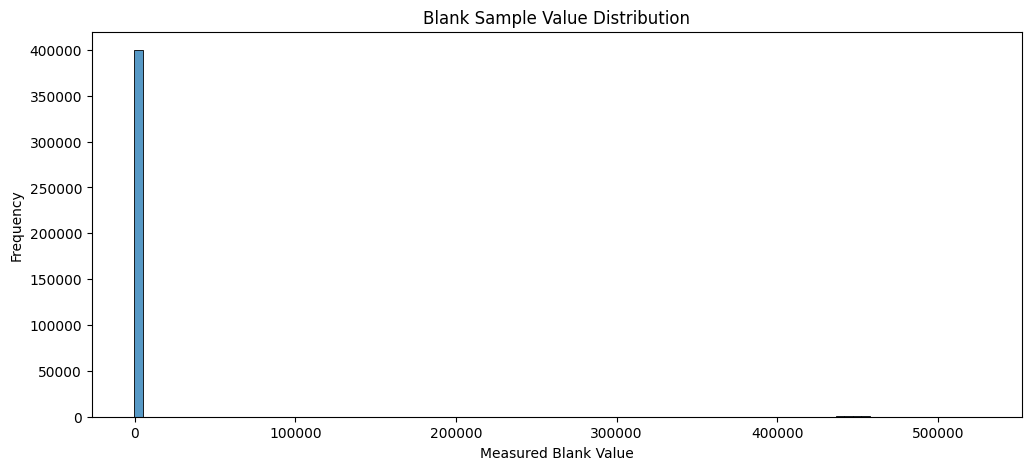

In [11]:
plt.figure(figsize=(12,5))

sns.histplot(
    blank_df["NUMERIC_FINAL_VALUE"],
    bins=100
)

plt.title(
    "Blank Sample Value Distribution"
)

plt.xlabel(
    "Measured Blank Value"
)

plt.ylabel(
    "Frequency"
)

plt.show()

#Filter out 

# Distribution Interpretation

The blank sample distribution shows that most observations are concentrated near zero, which matches the expected behaviour of laboratory blank materials.

However, the distribution also contains a small number of extremely large values. These sparse spikes may represent contamination events, analytical carryover, or abnormal laboratory behaviour.

The distribution is highly right-skewed and non-Gaussian, meaning traditional normal-distribution assumptions may not be appropriate for this anomaly type.

This supports the use of anomaly detection approaches such as Isolation Forest, which can identify sparse abnormal behaviour without assuming normally distributed data.

# Feature Engineering

Additional features were created to support contextual blank anomaly detection.

These features help measure:
- deviation from expected blank behaviour,
- analyte-specific abnormality,
- and temporal contamination patterns.

This supports the detection of:
- point anomalies,
- collective anomalies,
- and contextual anomalies described in the QC blank sample specifications.

In [12]:
blank_df["Deviation"] = (
    blank_df["NUMERIC_FINAL_VALUE"]
    - blank_df["INTERNAL_TARGET_VALUE"]
)

# Analyte-Specific Standardisation

Blank sample behaviour may vary across analytes due to differences in analytical sensitivity, background noise, and measurement scale.

To address this, analyte-specific z-scores were calculated to identify unusually elevated blank values relative to the normal behaviour of the same analyte population.

In [13]:
blank_df["AnalyteZScore"] = (
    blank_df.groupby("ANALYTE_CODE")
    ["NUMERIC_FINAL_VALUE"]
    .transform(
        lambda x:
        (x - x.mean()) / x.std()
    )
)

# Temporal Contamination Behaviour

Rolling statistical features were generated to investigate whether blank contamination behaviour changes over time.

This supports the detection of collective anomalies such as gradual baseline drift or repeated contamination patterns across historical QC batches.

In [14]:
blank_df = blank_df.sort_values(
    "ANALYSED_DATE"
)

blank_df["RollingMean"] = (
    blank_df.groupby("ANALYTE_CODE")
    ["NUMERIC_FINAL_VALUE"]
    .transform(
        lambda x:
        x.rolling(
            10,
            min_periods=1
        ).mean()
    )
)

# Feature Engineering Validation

The generated anomaly-detection features were inspected to confirm that deviation, analyte-specific behaviour, and temporal contamination features were successfully created for downstream anomaly modelling.

In [15]:
blank_df[
    [
        "NUMERIC_FINAL_VALUE",
        "Deviation",
        "AnalyteZScore",
        "RollingMean",
        "ANALYTE_CODE"
    ]
].head(10)

,NUMERIC_FINAL_VALUE,Deviation,AnalyteZScore,RollingMean,ANALYTE_CODE
3181,0.00143,0.00143,-0.107118,0.001430,W
3186,0.00089,0.00089,0.119071,0.000890,TE
3179,0.00083,0.00083,0.007085,0.000830,SB
3265,0.00020,0.00020,0.006889,0.000515,SB
3267,-0.00016,-0.00016,-0.107829,0.000635,W
3275,0.00120,0.00120,0.119194,0.001045,TE
3134,0.00051,0.00051,0.006986,0.000513,SB
3129,-0.00023,-0.00023,-0.107861,0.000347,W
3120,0.00060,0.00060,0.118955,0.000897,TE
3114,0.00210,0.00210,0.119553,0.001197,TE


# Candidate Predictive Models for Blank Sample Anomaly Detection

Several anomaly detection approaches were investigated for Blank Sample behaviour.

Because blank observations are expected to remain near zero and contain sparse contamination-like spikes, the data is highly skewed, mostly unlabeled, and non-Gaussian.

This makes unsupervised anomaly detection approaches more suitable for the MVP framework.

In [16]:
candidate_models = {
    "Rule-Based Thresholding":
        "Simple QC limit checks for elevated blank values",

    "Rolling Statistical Monitoring":
        "Detects gradual baseline drift over time",

    "Isolation Forest":
        "Detects sparse contamination anomalies in unlabeled data",

    "Local Outlier Factor":
        "Detects local contextual outliers within analyte groups",

    "One-Class SVM":
        "Learns normal blank behaviour patterns"
}

candidate_models

{'Rule-Based Thresholding': 'Simple QC limit checks for elevated blank values',
 'Rolling Statistical Monitoring': 'Detects gradual baseline drift over time',
 'Isolation Forest': 'Detects sparse contamination anomalies in unlabeled data',
 'Local Outlier Factor': 'Detects local contextual outliers within analyte groups',
 'One-Class SVM': 'Learns normal blank behaviour patterns'}